Whisper

- 音声を transcribe
- 各ステップごとの beam 候補・スコアを記録
- 推移の可視化（matplotlib）

In [1]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn.functional as F
from typing import Tuple
import pandas as pd
import matplotlib.pyplot as plt

from transformers import WhisperProcessor, WhisperForConditionalGeneration
from whisper.decoding import BeamSearchDecoder
from whisper.tokenizer import get_tokenizer
from whisper import load_model, load_audio

# --- パス検索関数の直接定義 ---
def get_path(session_num, cond, ext):
    base_dir = "/home/medical/WorkSpace/MedWhisper_nachi"
    # 条件名（例: "右前"）と拡張子（"wav" や "m4a"）に一致するファイルを再帰的に検索
    pattern = f"{base_dir}/**/*{cond}*.{ext}"
    matched_files = sorted(glob.glob(pattern, recursive=True))
    
    if not matched_files:
        raise FileNotFoundError(f"ファイルが見つかりませんでした: 条件='{cond}', 拡張子='{ext}'")
    
    # 該当セッション番号（1始まり）に応じたファイルを選択（範囲外なら末尾/先頭を安全に取得）
    idx = session_num - 1 if 0 <= session_num - 1 < len(matched_files) else 0
    return matched_files[idx]

# --- パラメータ設定 ---
session_number = 5
condition = "右前"
extension = "wav"  # 必要に応じて "m4a" などに変更
beam_size = 3

# 音声ファイルパスの取得
mov_path = get_path(session_number, condition, extension)
print("取得したファイルパス:", mov_path)

# --- シード値の固定 ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

/home/medical/WorkSpace/MedWhisper_nachi/venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


取得したファイルパス: /home/medical/WorkSpace/MedWhisper_nachi/0604data/5回目_右前.wav


In [ ]:
# mov_path = "/root/ikadai/右後ろ_2回目.MOV"

In [2]:
model = load_model("large-v3-turbo")#, device="cuda")
model.eval()

tokenizer = get_tokenizer(multilingual=True, task="transcribe")

In [3]:
#変更０８２３
import whisper
from whisper.tokenizer import get_tokenizer
from src.beam_hook import install_beam_hook, BiasConfig, InspectConfig, LogConfig

# 1. Tokenizerの取得（日本語設定、multilingualモデル用）
# すでに上のセルで model を作成している場合は model.is_multilingual や model.num_languages を参照できます
tokenizer = get_tokenizer(multilingual=True, language="ja", task="transcribe")

# 2. バイアスをかけたい専門用語リスト
domain_terms = [
    # "傷", "周囲", "体", "胸" など必要に応じて指定（空リスト [] でも可）
]

# 3. 各種コンフィグの初期化
bias_cfg = BiasConfig()
log_cfg = LogConfig()
inspect_cfg = InspectConfig(
    enable_inspect=True,
    topk=5,
    targets=["傷", "周囲", "体", "胸"],
    force_bonus=50,
    lock_after_hit=True,
)

# 4. フックの適用
original_update, hook_state = install_beam_hook(
    tokenizer=tokenizer,
    domain_terms=domain_terms,
    bias_cfg=bias_cfg,
    log_cfg=log_cfg,
    inspect_cfg=inspect_cfg
)

In [ ]:
"""from whisper.decoding import BeamSearchDecoder
from src.beam_hook import beam_update, beam_log, step

BeamSearchDecoder.update = beam_update"""

TypeError: install_beam_hook() missing 4 required positional arguments: 'tokenizer', 'domain_terms', 'bias_cfg', and 'log_cfg'

In [4]:
audio = load_audio(str(mov_path))
result = model.transcribe(audio, beam_size=beam_size ,initial_prompt = "傷病者 感染防御 胸骨圧迫")#,temperature=1)

print("=== 最終テキスト ===")
print(result["text"])

=== 最終テキスト ===
傷病者発見 新南全4 感染防御 配慮します大丈夫ですか 大丈夫ですか 誰か来てくださいまた AEDお願いします パンター119番お願いしますおらずここに戻ってきてください逆呼吸ともに胸骨圧迫を開始しますAED持ってきましたあなたはAED使えますか 使えませんでは私の隣においてください胸骨圧迫は胸骨圧迫は私と変わってください1,2,3で変わります1,2,31,2,3、4、3、4、4、4、5、6、4、5、5、6、5、7、6、6、7、6、6、6、6、6、6、8、6、6、6、7、6、5、6、7、6、7、13,6、9、14、7、10、7、 Nedth心電図を体積中です体に振る舞いでください振る舞いでくださいショックが必要です充電中です体から離れてくださいショックを実行しますショックが完了しました一時中断中です直ち胸骨圧迫と人工呼吸をしてください3分前にこの人が倒れているのを見ましたAEDと胸骨圧迫はありました身体は分かりませんがそこに保護した荷物がありますありがとうございますありがとうございます prioritiesイナス!"ご視聴ありがとうございました


In [5]:
# hook_state からログ情報を取り出す（追加）
beam_log = hook_state.get("beam_log", hook_state)
log_df = pd.DataFrame(beam_log)
print("=== Beam Log の先頭 ===")
print(log_df.head())

# ファイル保存
csv_path = f"initialbeam_search_steps_{condition}_{session_number}.csv"
csv_path ="川村先生音声.csv"
log_df.to_csv(csv_path, index=False)
print(f"保存: {csv_path}")

# ===============================
# 🔸7. 読みやすいテキスト形式で保存
# ===============================
output_lines = []

df = pd.read_csv(csv_path)

# カラム名に含まれる余計な空白を除去（念のための安全策）
df.columns = df.columns.str.strip()

#変更０８２３
for step in sorted(df["step"].unique()):
    output_lines.append(f"=== Step {step} ===")
    df_step = df[df["step"] == step]
    
    for _, row in df_step.iterrows():
        # 現在のCSVのカラム構成（step, beam, prefix, lock_remaining_len）に合わせて整形
        beam_idx = row['beam']
        prefix_text = row['prefix']
        lock_len = row.get('lock_remaining_len', 0)
        
        line = f"  Beam {beam_idx}: Prefix: 「{prefix_text}」 (Lock残り: {lock_len})"
        output_lines.append(line)
        
    output_lines.append("")  # ステップ間の空行

# 結果を画面に表示（先頭部分の確認用）
print("\n".join(output_lines[:30]))
#変更終わり

# テキスト保存
txt_path = f"iiibeam_trace_output_{condition}_{session_number}.txt"
txt_path = "川村先生.txt"
with open(txt_path, "w", encoding="utf-8") as f:
    f.write("\n".join(output_lines))

print(f"✅ テキスト出力: {txt_path}")

=== Beam Log の先頭 ===
            t_ms  step  beam     score  sum_logprob logprobs_where  \
0  1787448830642     0     0 -0.086990    -0.086990         args:1   
1  1787448830642     0     1 -5.142166    -5.142166         args:1   
2  1787448830642     0     2 -5.528885    -5.528885         args:1   
3  1787448830664     1     0 -0.086990    -0.086990         args:1   
4  1787448830664     1     1 -5.528885    -5.528885         args:1   

  prefix_source  prefix_len  \
0       args[0]          23   
1       args[0]          23   
2       args[0]          23   
3       args[0]          24   
4       args[0]          24   

                                     prefix_tail_ids  \
0  [46568, 35863, 2172, 94, 220, 19095, 116, 165,...   
1  [46568, 35863, 2172, 94, 220, 19095, 116, 165,...   
2  [46568, 35863, 2172, 94, 220, 19095, 116, 165,...   
3  [35863, 2172, 94, 220, 19095, 116, 165, 16838,...   
4  [35863, 2172, 94, 220, 19095, 116, 165, 16838,...   

                                  

/tmp/ipykernel_4129441/295199978.py:28: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4129441/295199978.py:28: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4129441/295199978.py:31: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from current font.
  plt.savefig(save_path)
/tmp/ipykernel_4129441/295199978.py:31: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.savefig(save_path)


グラフを保存しました: beam_log_右前_5.png


/home/medical/WorkSpace/MedWhisper_nachi/venv/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/medical/WorkSpace/MedWhisper_nachi/venv/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


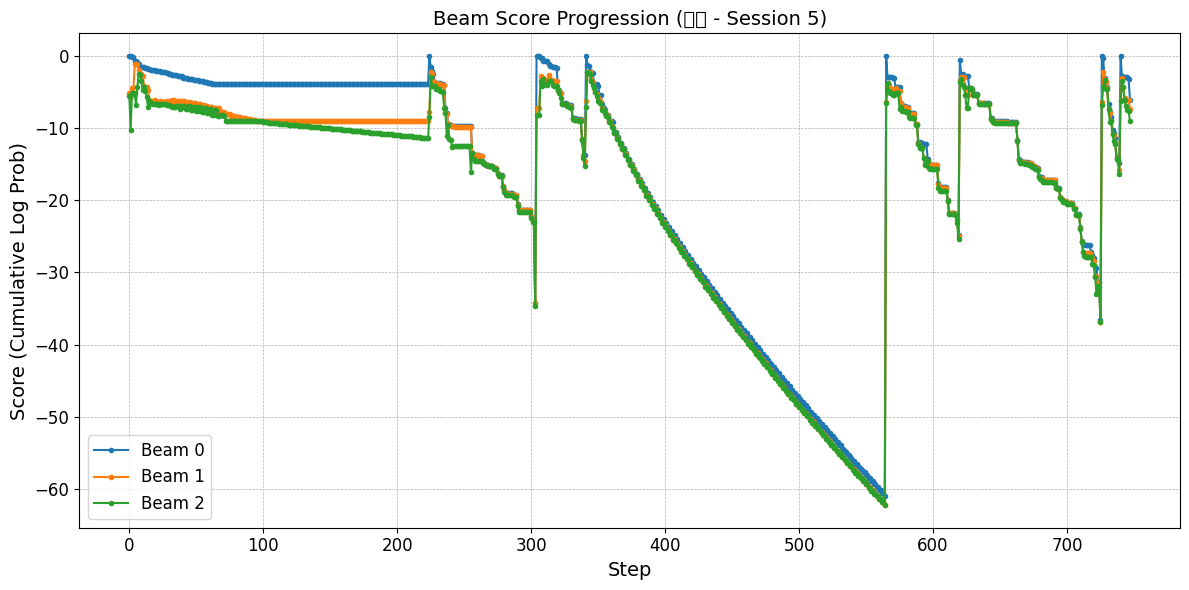

'plt.figure(figsize=(12, 6))\nfor beam_id in best_per_beam["beam"].unique():\n    df_beam = best_per_beam[best_per_beam["beam"] == beam_id]\n    plt.plot(df_beam["step"], df_beam["score"], label=f"Beam {beam_id}")\n\nplt.xlabel("Step", fontsize=14)\nplt.ylabel("Score (-log prob)", fontsize=14)\nplt.xticks(fontsize=12)\nplt.yticks(fontsize=12)\nplt.legend(fontsize=12)\nplt.grid(True, which=\'both\', linestyle=\'--\', linewidth=0.5)\nplt.tight_layout()\nplt.savefig(f"beam_log_{condition}_{session_number}")\nplt.show()'

In [6]:
# ===============================
#追加０８２３
# ログをDataFrame化
log_df = pd.DataFrame(hook_state.get("beam_log", []))
#追加終わり

# 各 step × beam ごとに最良スコアのものを抽出
best_per_beam = (
    log_df.sort_values("score", ascending=False)
    .groupby(["step", "beam"])
    .first()
    .reset_index()
)

#追加０８２３
plt.figure(figsize=(12, 6))
for beam_id in sorted(best_per_beam["beam"].unique()):
    df_beam = best_per_beam[best_per_beam["beam"] == beam_id]
    plt.plot(df_beam["step"], df_beam["score"], label=f"Beam {beam_id}", marker='o', markersize=3)

plt.xlabel("Step", fontsize=14)
plt.ylabel("Score (Cumulative Log Prob)", fontsize=14)
plt.title(f"Beam Score Progression ({condition} - Session {session_number})", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

save_path = f"beam_log_{condition}_{session_number}.png"
plt.savefig(save_path)
print(f"グラフを保存しました: {save_path}")
plt.show()
#追加終わり

"""plt.figure(figsize=(12, 6))
for beam_id in best_per_beam["beam"].unique():
    df_beam = best_per_beam[best_per_beam["beam"] == beam_id]
    plt.plot(df_beam["step"], df_beam["score"], label=f"Beam {beam_id}")

plt.xlabel("Step", fontsize=14)
plt.ylabel("Score (-log prob)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(f"beam_log_{condition}_{session_number}")
plt.show()"""


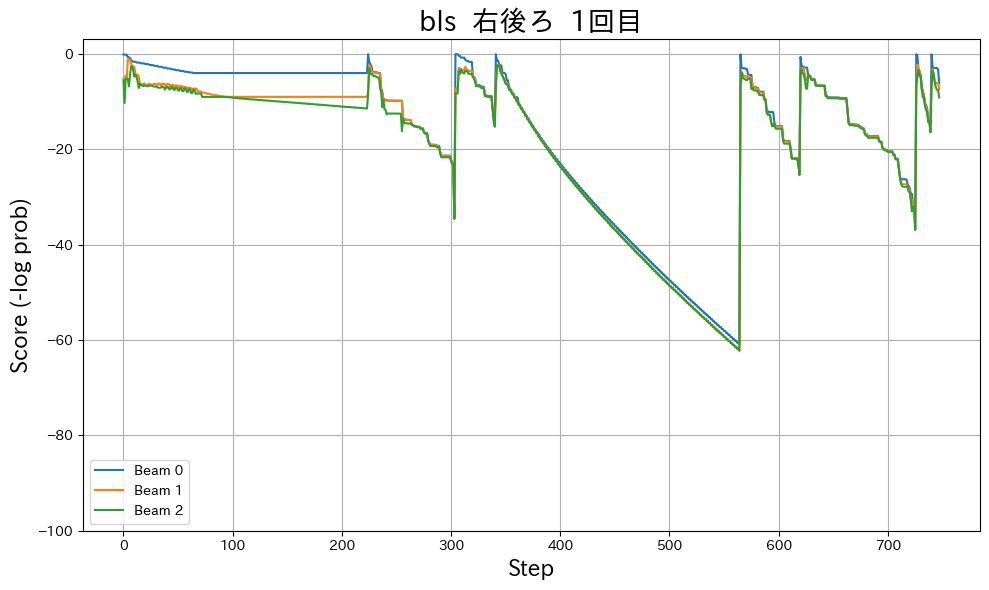

✅ PNG保存: beam_log_右後ろ_1.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

condition ="右後ろ"
session_number =1
csv_path = f"beam_search_steps_{condition}_{session_number}.csv"
#追加０８２３
df_save = pd.DataFrame(hook_state.get("beam_log", []))
df_save.to_csv(csv_path, index=False, encoding="utf-8-sig")
#追加終わり
df = pd.read_csv(csv_path)


best_per_beam = (
    df.sort_values("score", ascending=False)
    .groupby(["step", "beam"])
    .first()
    .reset_index()
)

# グラフ描画
plt.figure(figsize=(10, 6))
for beam_id in best_per_beam["beam"].unique():
    df_beam = best_per_beam[best_per_beam["beam"] == beam_id]
    plt.plot(df_beam["step"], df_beam["score"], label=f"Beam {beam_id}")

plt.xlabel("Step", fontsize=16)
plt.ylabel("Score (-log prob)", fontsize=16)
plt.ylim(-100,)
plt.title(f"bls  {condition}  {session_number}回目", fontsize=20)
plt.legend()
plt.grid(True)
plt.tight_layout()

# 🔽 PNGファイルとして保存
png_path = f"beam_log_{condition}_{session_number}.png"
plt.savefig(png_path, dpi=300)
plt.show()

print(f"✅ PNG保存: {png_path}")


In [12]:
# ===============================
# 🔸 指定ステップのビームログ表示
# ===============================
target_step = 0  # ← ここを表示したいステップ番号に変更！

df_step = df[df["step"] == target_step]
print(f"\nStep {target_step}:")

#追加０８２３
for _, row in df_step.iterrows():
    beam_idx = row['beam']
    prefix_text = row.get('prefix', '')
    score = float(row['score']) if 'score' in row and pd.notna(row['score']) else 0.0
    lock_len = row.get('lock_remaining_len', 0)
    
    # 存在するカラムに合わせて出力
    print(f"  Beam {beam_idx}: Prefix: 「{prefix_text}」 (score: {score:.2f}, Lock残り: {lock_len})")
#追加終わり

"""for _, row in df_step.iterrows():
    print(f"  Beam {row.beam} ← Beam {row.source_beam}: {row.prefix} + 「{row.next_token_str}」 → {row.new_seq}  (score: {row.score:.2f})")
"""


Step 0:
  Beam 0: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>」 (score: -0.09, Lock残り: 0)
  Beam 1: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>」 (score: -5.14, Lock残り: 0)
  Beam 2: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>」 (score: -5.53, Lock残り: 0)


'for _, row in df_step.iterrows():\n    print(f"  Beam {row.beam} ← Beam {row.source_beam}: {row.prefix} + 「{row.next_token_str}」 → {row.new_seq}  (score: {row.score:.2f})")\n'

In [14]:
# ===============================
# 🔸 スコア条件で全ログからフィルタして表示
# ===============================
score_threshold = -3  # この値より大きい（= 0に近い）スコアを対象

df_filtered = df[df["score"] >= score_threshold]

#追加０８２３
for _, row in df_filtered.iterrows():
    step = row['step']
    beam = row['beam']
    prefix = row.get('prefix', '')
    score = float(row['score']) if pd.notna(row['score']) else 0.0
    lock_len = row.get('lock_remaining_len', 0)
    
    print(f"Step {step}: Beam {beam}: Prefix: 「{prefix}」 (score: {score:.2f}, Lock残り: {lock_len})")
#追加終わり

"""for _, row in df_filtered.iterrows():
    print(f"Step {row.step}: Beam {row.beam} ← Beam {row.source_beam}: {row.prefix} + 「{row.next_token_str}」 → {row.new_seq}  (score: {row.score:.2f})")
"""


Step 0: Beam 0: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>」 (score: -0.09, Lock残り: 0)
Step 1: Beam 0: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>」 (score: -0.09, Lock残り: 0)
Step 2: Beam 0: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>傷」 (score: -0.12, Lock残り: 0)
Step 3: Beam 0: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>傷病」 (score: -0.13, Lock残り: 0)
Step 4: Beam 0: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>傷病者」 (score: -0.67, Lock残り: 0)
Step 4: Beam 1: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>傷症」 (score: -1.16, Lock残り: 0)
Step 5: Beam 0: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>傷病者発」 (score: -0.68, Lock残り: 0)
Step 5: Beam 1: Prefix: 「<|nospeech|> 傷病者 感染防御 胸骨圧迫<|startoftranscript|><|ja|><|startoflm|>傷病者」 (score: -1.16, Lock残り: 0)
Step 6: Beam 0: Prefix: 「<|nospee

'for _, row in df_filtered.iterrows():\n    print(f"Step {row.step}: Beam {row.beam} ← Beam {row.source_beam}: {row.prefix} + 「{row.next_token_str}」 → {row.new_seq}  (score: {row.score:.2f})")\n'

In [17]:
import re
import pykakasi

# pykakasi の最新 API で漢字・カタカナをすべて平仮名へ統一
kks = pykakasi.kakasi()

def to_hiragana(text):
    result = kks.convert(text)
    # すべてひらがな（hira）に変換して結合
    return "".join([item['hira'] for item in result])

def remove_punctuation(text):
    return re.sub(r'[、。,\. \s]', '', text)

def check_words(transcribed_text, words_to_check):
    cleaned_text = to_hiragana(remove_punctuation(transcribed_text))
    print(f"【実際の認識テキスト（ひらがな化）】:\n{cleaned_text}\n")
    print("=== 🎯 BLS キーワード判定結果 ===")
    
    results = {}
    for word in words_to_check:
        cleaned_word = to_hiragana(remove_punctuation(word))
        is_found = cleaned_word in cleaned_text
        results[word] = is_found
        mark = "✅" if is_found else "❌"
        print(f"{mark} {word:<18} (探索キー: '{cleaned_word}') : {is_found}")
    return results

correct_words = [
    '周囲の安全よし', '傷病者発見', '感染防御よし', '大丈夫ですか', 
    '誰か来てください', 'あなた119番通報してください', 'あなたAEDを持ってきてください',
    '呼吸の確認', '脈の確認', '1 2 3', 'ショック', '荷物'
]

# ★ ここに実際の推論結果オブジェクト（例: result や transcription_result）を指定します
# もし変数名が不明な場合は `result['text']` の部分をご自身の推論結果変数名に合わせてください
transcribed_text = result["text"]  

# 判定実行
check_words(transcribed_text, correct_words)

【実際の認識テキスト（ひらがな化）】:
しょうびょうものはっけんしんみなみぜん4かんせんぼうぎょはいりょしますだいじょうぶですかだいじょうぶですかだれかきてくださいまたAEDおねがいしますぱんたー119ばんおねがいしますおらずここにもどってきてくださいぎゃくこきゅうともにきょうこつあっぱくをかいししますAEDもってきましたあなたはAEDつかえますかつかえませんではわたしのとなりにおいてくださいきょうこつあっぱくはきょうこつあっぱくはわたしとかわってください123でかわります1231234344456455657667666666866676567671369147107Nedthしんでんずをたいせきなかですからだにふるまいでくださいふるまいでくださいしょっくがひつようですじゅうでんちゅうですからだからはなれてくださいしょっくをじっこうしますしょっくがかんりょうしましたいちじちゅうだんなかですただちきょうこつあっぱくとじんこうこきゅうをしてください3ふんまえにこのにんがたおれているのをみましたAEDときょうこつあっぱくはありましたしんたいはわかりませんがそこにほごしたにもつがありますありがとうございますありがとうございますprioritiesいなす!"ごしちょうありがとうございました

=== 🎯 BLS キーワード判定結果 ===
❌ 周囲の安全よし            (探索キー: 'しゅういのあんぜんよし') : False
✅ 傷病者発見              (探索キー: 'しょうびょうものはっけん') : True
❌ 感染防御よし             (探索キー: 'かんせんぼうぎょよし') : False
✅ 大丈夫ですか             (探索キー: 'だいじょうぶですか') : True
✅ 誰か来てください           (探索キー: 'だれかきてください') : True
❌ あなた119番通報してください    (探索キー: 'あなた119ばんつうほうしてください') : False
❌ あなたAEDを持ってきてください   (探索キー: 'あなたAEDをもってきてください') : False
❌ 呼吸の確認              (探索キー: 'こきゅうのかくにん') : False
❌ 脈の確認        

{'周囲の安全よし': False,
 '傷病者発見': True,
 '感染防御よし': False,
 '大丈夫ですか': True,
 '誰か来てください': True,
 'あなた119番通報してください': False,
 'あなたAEDを持ってきてください': False,
 '呼吸の確認': False,
 '脈の確認': False,
 '1 2 3': True,
 'ショック': True,
 '荷物': True}

In [ ]:
#追加０８２３
# 1. 実際にWhisperが出力した生のテキストを表示
print("【1. Whisperの生テキスト】:")
print(repr(transcribed_text))

# 2. ひらがな・記号除去後のテキストを表示
cleaned_text = to_hiragana(remove_punctuation(transcribed_text))
print("\n【2. ひらがな化テキスト】:")
print(repr(cleaned_text))

# 3. 判定対象の単語（ひらがな化後）一覧を表示
print("\n【3. 探している単語（ひらがな）】:")
for w in correct_words:
    print(f"・{w} → {repr(to_hiragana(remove_punctuation(w)))}")

【1. Whisperの生テキスト】:
'傷病者発見 新南全4 感染防御 配慮します大丈夫ですか 大丈夫ですか 誰か来てくださいまた AEDお願いします パンター119番お願いしますおらずここに戻ってきてください逆呼吸ともに胸骨圧迫を開始しますAED持ってきましたあなたはAED使えますか 使えませんでは私の隣においてください胸骨圧迫は胸骨圧迫は私と変わってください1,2,3で変わります1,2,31,2,3、4、3、4、4、4、5、6、4、5、5、6、5、7、6、6、7、6、6、6、6、6、6、8、6、6、6、7、6、5、6、7、6、7、13,6、9、14、7、10、7、 Nedth心電図を体積中です体に振る舞いでください振る舞いでくださいショックが必要です充電中です体から離れてくださいショックを実行しますショックが完了しました一時中断中です直ち胸骨圧迫と人工呼吸をしてください3分前にこの人が倒れているのを見ましたAEDと胸骨圧迫はありました身体は分かりませんがそこに保護した荷物がありますありがとうございますありがとうございます prioritiesイナス!"ご視聴ありがとうございました'

【2. ひらがな化テキスト】:
'しょうびょうものはっけんしんみなみぜん4かんせんぼうぎょはいりょしますだいじょうぶですかだいじょうぶですかだれかきてくださいまたAEDおねがいしますぱんたー119ばんおねがいしますおらずここにもどってきてくださいぎゃくこきゅうともにきょうこつあっぱくをかいししますAEDもってきましたあなたはAEDつかえますかつかえませんではわたしのとなりにおいてくださいきょうこつあっぱくはきょうこつあっぱくはわたしとかわってください123でかわります1231234344456455657667666666866676567671369147107Nedthしんでんずをたいせきなかですからだにふるまいでくださいふるまいでくださいしょっくがひつようですじゅうでんちゅうですからだからはなれてくださいしょっくをじっこうしますしょっくがかんりょうしましたいちじちゅうだんなかですただちきょうこつあっぱくとじんこうこきゅうをしてください3ふんまえにこのにんがたおれているのをみましたAEDときょうこつあっぱくはありましたしんたいはわかりませんがそこにほごしたにもつがありますあり